In [1]:
import numpy as np

# ── Step 1: Get user input ──────────────────────────────────────────────
number = int(input("Enter a number (0-9): "))

# ── Step 2: Activation function ────────────────────────────────────────
# The "step function" — if the weighted sum is 0 or more, fire (output 1)
# otherwise don't fire (output 0). This is how the neuron makes a decision.
def step_function(weighted_sum):
    return 1 if weighted_sum >= 0 else 0

# ── Step 3: Training data ───────────────────────────────────────────────
# Each number 0–9 is stored as its 6-bit binary form.
# The label tells us the correct answer: 1 = even, 0 = odd.
# Notice: the first two bits are always 1 — they act as a bias
# (a constant nudge that helps the neuron learn the decision boundary).
training_data = [
    {"input": [1, 1, 0, 0, 0, 0], "label": 1},  # 0 → even
    {"input": [1, 1, 0, 0, 0, 1], "label": 0},  # 1 → odd
    {"input": [1, 1, 0, 0, 1, 0], "label": 1},  # 2 → even
    {"input": [1, 1, 0, 0, 1, 1], "label": 0},  # 3 → odd
    {"input": [1, 1, 0, 1, 0, 0], "label": 1},  # 4 → even
    {"input": [1, 1, 0, 1, 0, 1], "label": 0},  # 5 → odd
    {"input": [1, 1, 0, 1, 1, 0], "label": 1},  # 6 → even
    {"input": [1, 1, 0, 1, 1, 1], "label": 0},  # 7 → odd
    {"input": [1, 1, 1, 0, 0, 0], "label": 1},  # 8 → even
    {"input": [1, 1, 1, 0, 0, 1], "label": 0},  # 9 → odd
]

# ── Step 4: Initialize weights ──────────────────────────────────────────
# We start with a small guess: weight 1 on the last bit (the LSB),
# and 0 everywhere else. The Perceptron will correct these over training.
weights = np.array([0, 0, 0, 0, 0, 1])

# ── Step 5: Training loop ───────────────────────────────────────────────
# We show the Perceptron each training example one by one.
# If it gets one wrong, we nudge the weights to do better next time.
# This is the core Perceptron Learning Rule: w = w + (error × input)
print("\n--- Training ---")
for example in training_data:
    bits         = np.array(example["input"])
    correct      = example["label"]

    # Make a prediction using current weights
    weighted_sum = np.dot(bits, weights)
    prediction   = step_function(weighted_sum)

    # Error is +1 (missed a 1), -1 (wrongly said 1), or 0 (correct)
    error = correct - prediction

    # Update weights — only changes when error != 0
    weights = weights + (bits * error)

    result = "correct" if error == 0 else f"wrong (error={error:+d}) → weights updated"
    print(f"  Input {bits.tolist()}  label={correct}  predicted={prediction}  {result}")

print(f"\nFinal weights learned: {weights.tolist()}")

# ── Step 6: Classify the user's number ─────────────────────────────────
# Convert the number to a 6-bit binary list, e.g. 6 → [0, 0, 0, 1, 1, 0]
binary_digits  = [int(b) for b in f"{number:06b}"]
weighted_sum   = np.dot(binary_digits, weights)
prediction     = step_function(weighted_sum)

label = "even" if prediction == 1 else "odd"
print(f"\n{number} in binary → {binary_digits}")
print(f"Weighted sum = {weighted_sum}  →  step({weighted_sum}) = {prediction}")
print(f"Result: {number} is {label}")

Enter a number (0-9): 3

--- Training ---
  Input [1, 1, 0, 0, 0, 0]  label=1  predicted=1  correct
  Input [1, 1, 0, 0, 0, 1]  label=0  predicted=1  wrong (error=-1) → weights updated
  Input [1, 1, 0, 0, 1, 0]  label=1  predicted=0  wrong (error=+1) → weights updated
  Input [1, 1, 0, 0, 1, 1]  label=0  predicted=1  wrong (error=-1) → weights updated
  Input [1, 1, 0, 1, 0, 0]  label=1  predicted=0  wrong (error=+1) → weights updated
  Input [1, 1, 0, 1, 0, 1]  label=0  predicted=1  wrong (error=-1) → weights updated
  Input [1, 1, 0, 1, 1, 0]  label=1  predicted=0  wrong (error=+1) → weights updated
  Input [1, 1, 0, 1, 1, 1]  label=0  predicted=1  wrong (error=-1) → weights updated
  Input [1, 1, 1, 0, 0, 0]  label=1  predicted=0  wrong (error=+1) → weights updated
  Input [1, 1, 1, 0, 0, 1]  label=0  predicted=0  correct

Final weights learned: [0, 0, 1, 0, 0, -3]

3 in binary → [0, 0, 0, 0, 1, 1]
Weighted sum = -3  →  step(-3) = 0
Result: 3 is odd


The weight update rule weights += input * error is the Perceptron Learning Rule, and it is elegant in its simplicity. Let's trace through what each case of error actually means:
When error = 0 (correct prediction), input × 0 = 0, so weights don't change at all. When error = +1 (predicted 0, should be 1), the weights of all active inputs are increased — we want the neuron to fire next time. When error = -1 (predicted 1, should be 0), the weights of all active inputs are decreased — we want to suppress firing next time.
Think of it like adjusting volume knobs: turn up the inputs that should have contributed to a "yes", turn down the ones that contributed to a wrong "yes".

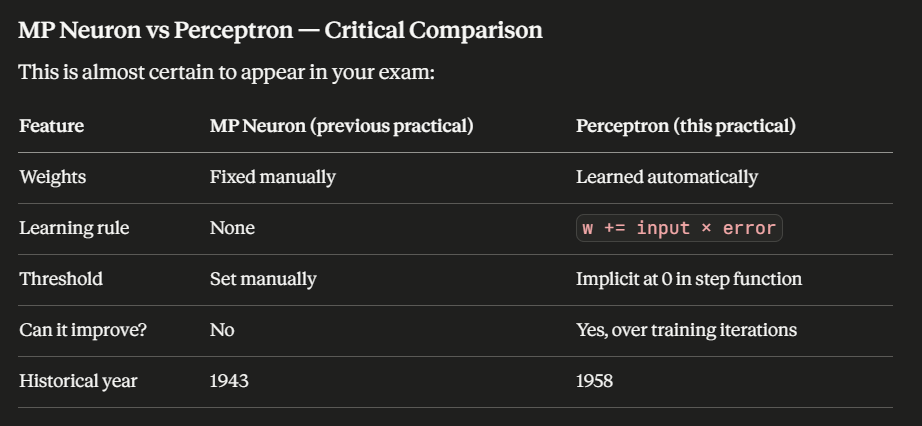

Q1. What is the Perceptron learning rule?
weights = weights + (input × error), where error = label − output. When the prediction is correct, no update happens. When it's wrong, weights shift in the direction that would have produced the correct answer.

Q2. Why do we start weights as [0,0,0,0,0,1] and not all zeros?
Starting all-zero weights would mean the initial dot product is always 0, and step_function(0) = 1. The last weight being 1 gives a reasonable initial bias toward checking the LSB, which is the actual deciding bit for even/odd. In general though, Perceptrons can start anywhere — including random small values — and still converge.

Q3. What does the binary format '{0:06b}'.format(j) do?
It converts integer j into a 6-character binary string, zero-padded on the left. For example, j=3 gives '000011', which becomes [0,0,0,0,1,1].

Q4. What is the Perceptron convergence theorem?
If the training data is linearly separable (a hyperplane can divide the two classes), the Perceptron is guaranteed to converge — that is, find a set of weights that classifies all training examples correctly — in a finite number of steps. Even/odd classification is linearly separable (only the LSB matters), so it always converges.

Q5. What is the limitation of a single Perceptron?
It can only learn linearly separable problems. XOR, for example, cannot be learned by a single Perceptron. This limitation, famously pointed out by Minsky and Papert in 1969, led to a temporary decline in neural network research — until multi-layer networks revived the field.

Q6. How is the step function here different from the previous practical?
In the MP neuron, the threshold θ was an explicit parameter. Here, the step function fires when the sum ≥ 0, so the threshold is implicitly 0. This means the bias effect is handled entirely through the learned weights — a cleaner formulation.